## Import libraries


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bocon66/processed-rice-244")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'processed-rice-244' dataset.
Path to dataset files: /kaggle/input/processed-rice-244


## Load and prepare data

In [2]:
import os
import time
import numpy as np
import tensorflow as tf
import kagglehub
from datasets import load_from_disk
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

# ==========================================
# STEP 1: LOAD AND PREPARE DATA
# ==========================================

hf_dataset = load_from_disk(path)

# Extract class information
try:
    # This works if it was saved as a ClassLabel
    class_names = hf_dataset['train'].features['label'].names
except AttributeError:
    # This acts as a fallback if it was saved as a generic Value
    # We ask the dataset to find all unique labels in the training set
    unique_labels = hf_dataset['train'].unique('label')
    class_names = [str(label) for label in sorted(unique_labels)]

num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")
# Create a lookup layer to convert string labels (words) into integer indices (0, 1, 2...)
# We use the class_names list you extracted earlier!
label_encoder = tf.keras.layers.StringLookup(vocabulary=class_names, num_oov_indices=0)

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

def preprocess_for_tf(image, label):
    # Resize and format the image
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # Convert the string label to an integer label
    label = label_encoder(label)

    return image, label

print("Converting to TensorFlow datasets...")
train_dataset = hf_dataset["train"].to_tf_dataset(
    columns=["image"], label_cols=["label"], batch_size=BATCH_SIZE, shuffle=True
)
train_dataset = train_dataset.map(preprocess_for_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

validation_dataset = hf_dataset["validation"].to_tf_dataset(
    columns=["image"], label_cols=["label"], batch_size=BATCH_SIZE, shuffle=False
)
validation_dataset = validation_dataset.map(preprocess_for_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

Found 21 classes: ['Bacterial Leaf Blight', 'Bakanae Disease', 'Blast', 'Brown Plant Hopper', 'Brown Spot', 'Chilo Stem Borer', 'False Smut', 'Healthy', 'Hispa', 'Leaf Scald', 'Narrow Brown Spot', 'Nitrogen Deficiency', 'Phosphorus Deficiency', 'Potassium Deficiency', 'Rice Gall Midge', 'Rice Leaf Folder', 'Rice Skipper', 'Sheath Blight', 'Thrips', 'Tungro Virus', 'Yellow Stem Borer']
Converting to TensorFlow datasets...


/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


##  Build the model

In [3]:
# ==========================================
# STEP 2: BUILD THE MODEL
# ==========================================
print("Building ResNet50 Model...")
base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base layers

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

Building ResNet50 Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Training

In [4]:
# ==========================================
# STEP 3: TRAIN WITH TIME TRACKING
# ==========================================
EPOCHS = 10
print(f"Starting training for {EPOCHS} epochs...")

start_time = time.time() # Start stopwatch

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

end_time = time.time() # Stop stopwatch

total_train_time_sec = end_time - start_time
avg_epoch_time_sec = total_train_time_sec / EPOCHS

Starting training for 10 epochs...
Epoch 1/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 222s 248ms/step - accuracy: 0.9035 - loss: 0.3257 - val_accuracy: 0.9507 - val_loss: 0.1507
Epoch 2/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 182s 218ms/step - accuracy: 0.9744 - loss: 0.0894 - val_accuracy: 0.9795 - val_loss: 0.0778
Epoch 3/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 184s 222ms/step - accuracy: 0.9865 - loss: 0.0543 - val_accuracy: 0.9819 - val_loss: 0.0596
Epoch 4/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 201s 220ms/step - accuracy: 0.9928 - loss: 0.0336 - val_accuracy: 0.9839 - val_loss: 0.0567
Epoch 5/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 188s 226ms/step - accuracy: 0.9957 - loss: 0.0239 - val_accuracy: 0.9898 - val_loss: 0.0405
Epoch 6/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 179s 216ms/step - accuracy: 0.9974 - loss: 0.0171 - val_accuracy: 0.9900 - val_loss: 0.0381
Epoch 7/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 181s 218ms/step - accuracy: 0.9976 - loss: 0.0147 - val_accuracy: 0.9914 - val_loss: 0.0363
Epoch 8/10
831/831 ━━━━━━━━━━━━━━━━━━━━ 1

## Evauate & generate merrics

In [5]:
# ==========================================
# STEP 4: EVALUATE AND GENERATE METRICS
# ==========================================
print("Generating predictions on validation set for reporting...")

y_true = []
y_pred_probs = []

# Iterate through the validation dataset to get true labels and predictions
for images, labels in validation_dataset:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
# Convert probabilities to actual class predictions (0, 1, 2, etc.)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# Calculate metrics using scikit-learn
acc = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
class_report_str = classification_report(y_true, y_pred, target_names=class_names)

Generating predictions on validation set for reporting...


## Reporting

In [6]:
# ==========================================
# STEP 5: REPORT METRICS
# ==========================================
print("\n" + "="*40)
print("FINAL TRAINING REPORT")
print("="*40)
print(f"Total Training Time: {total_train_time_sec:.2f} seconds")
print(f"Average Epoch Time:  {avg_epoch_time_sec:.2f} seconds")
print("-" * 40)
print(f"Overall Accuracy:    {acc:.4f}")
print(f"Balanced Accuracy:   {balanced_acc:.4f}")
print("-" * 40)
print("Classification Report (includes Macro/Micro metrics per class):")
print(class_report_str)



FINAL TRAINING REPORT
Total Training Time: 1883.09 seconds
Average Epoch Time:  188.31 seconds
----------------------------------------
Overall Accuracy:    0.9905
Balanced Accuracy:   0.9912
----------------------------------------
Classification Report (includes Macro/Micro metrics per class):
                       precision    recall  f1-score   support

Bacterial Leaf Blight       1.00      0.99      0.99       442
      Bakanae Disease       1.00      1.00      1.00        15
                Blast       1.00      1.00      1.00       300
   Brown Plant Hopper       0.98      1.00      0.99        87
           Brown Spot       0.99      0.99      0.99       471
     Chilo Stem Borer       0.99      0.98      0.98       224
           False Smut       1.00      1.00      1.00        15
              Healthy       0.99      0.99      0.99       564
                Hispa       1.00      0.99      1.00       438
           Leaf Scald       1.00      0.98      0.99       501
    Narr

## Testing

Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


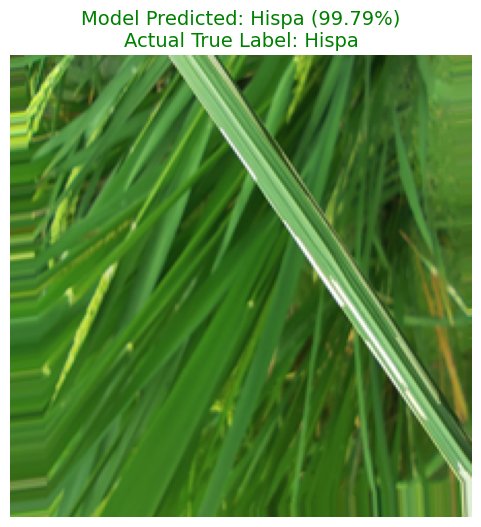

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Grab a single example from the validation set
# You can change the '0' to any other number to test different images
sample_index = 10
sample_example = hf_dataset['validation'][sample_index]

# Extract the raw image and the true text label
raw_image = sample_example['image']
true_label_text = sample_example['label']

# 2. Preprocess the image exactly like we did for training
# Resize to 224x224 and cast to float32
img_tensor = tf.image.resize(raw_image, (224, 224))
img_tensor = tf.cast(img_tensor, tf.float32)

# Neural networks expect a "batch" of images, not just one.
# We use expand_dims to change the shape from (224, 224, 3) to (1, 224, 224, 3)
img_batch = tf.expand_dims(img_tensor, 0)

# 3. Make the prediction
print("Running prediction...")
predictions = model.predict(img_batch)

# The model outputs a list of probabilities for each class.
# We use argmax to find the index of the highest probability.
predicted_index = np.argmax(predictions[0])
predicted_probability = np.max(predictions[0]) * 100

# Map the predicted index back to the human-readable class name
predicted_class_name = class_names[predicted_index]

# 4. Display the image and the results
plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.title(
    f"Model Predicted: {predicted_class_name} ({predicted_probability:.2f}%)\n"
    f"Actual True Label: {true_label_text}",
    fontsize=14,
    color='green' if predicted_class_name == true_label_text else 'red'
)
plt.axis('off')
plt.show()




## Saliency map

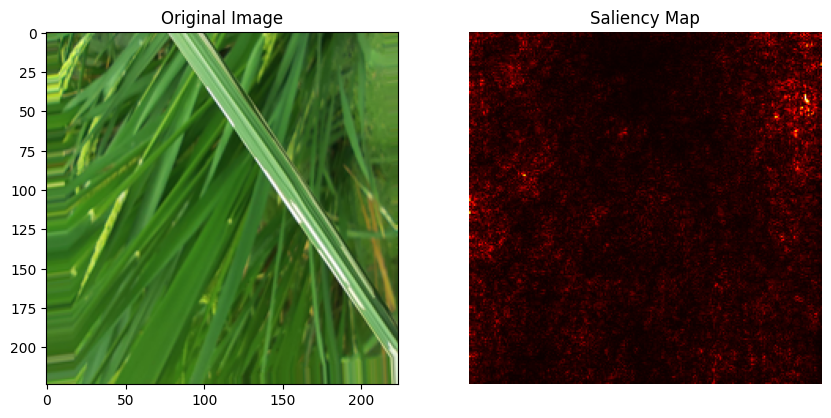

In [11]:
import matplotlib.pyplot as plt

def get_saliency_map(model, image, class_index):
    # Ensure the image is a tensor and we are watching it for gradients
    img_tensor = tf.convert_to_tensor(image)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        # Pass through the model
        predictions = model(img_tensor)
        # Get the prediction score for the specific class
        loss = predictions[:, class_index]

    # Calculate gradients of the loss with respect to the input image
    gradients = tape.gradient(loss, img_tensor)

    # Take the absolute value and maximum across color channels to get a 2D grayscale map
    saliency = tf.reduce_max(tf.abs(gradients), axis=-1)[0]

    return saliency.numpy()

# How to use it:
# (Assuming `img_batch` and `predicted_index` are from your previous single-image test)
saliency_map = get_saliency_map(model, img_batch, predicted_index)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_batch[0] / 255.0) # Normalize for displaying

plt.subplot(1, 2, 2)
plt.title("Saliency Map")
plt.imshow(saliency_map, cmap='hot')
plt.axis('off')
plt.show()

## Grad-CAM

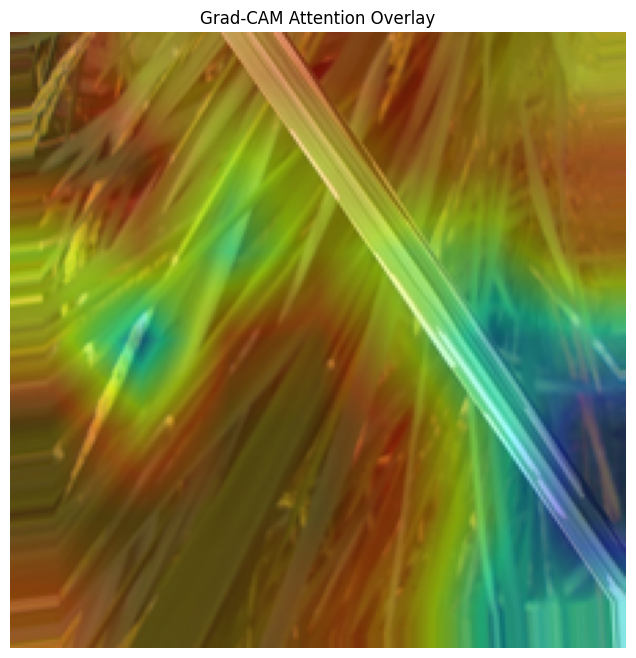

In [12]:
import cv2 # Make sure you have opencv-python installed (pip install opencv-python)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, full_model, last_conv_layer_name="conv5_block3_out"):
    # 1. Safely locate the nested ResNet50 model and the top layers
    resnet_model = None
    pooling_layer = None
    dense_layer = None

    for layer in full_model.layers:
        if isinstance(layer, tf.keras.Model): # Identifies the ResNet50 base model
            resnet_model = layer
        elif isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
            pooling_layer = layer
        elif isinstance(layer, tf.keras.layers.Dense):
            dense_layer = layer

    # 2. Create a sub-model that outputs BOTH the target conv layer and the final ResNet output
    grad_model = tf.keras.models.Model(
        [resnet_model.inputs],
        [resnet_model.get_layer(last_conv_layer_name).output, resnet_model.output]
    )

    # 3. Track the gradients
    with tf.GradientTape() as tape:
        # Run preprocessing
        inputs = tf.keras.applications.resnet50.preprocess_input(img_array)

        # Pass inputs through the ResNet sub-model
        last_conv_layer_output, resnet_output = grad_model(inputs)

        # Crucial step: Watch the conv layer output to track its gradients
        tape.watch(last_conv_layer_output)

        # Pass the ResNet output through your final pooling and dense layers
        x = pooling_layer(resnet_output)
        preds = dense_layer(x)

        # Get the highest predicted class
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Calculate gradients of the top class with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Weigh the feature map by the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize the heatmap to values between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ==========================================
# GENERATE AND DISPLAY THE OVERLAY
# ==========================================

# 1. Generate the heatmap
heatmap = make_gradcam_heatmap(img_batch, model)

# 2. Prepare the original image
# Note: we take the first image from the batch and ensure it is an 8-bit integer for cv2
img_to_show = (img_batch[0].numpy()).astype('uint8')

# 3. Resize heatmap to match the original image size
heatmap_resized = cv2.resize(heatmap, (img_to_show.shape[1], img_to_show.shape[0]))

# 4. Convert heatmap to RGB and apply a color map (JET creates the classic red-to-blue look)
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# 5. Overlay the heatmap onto the original image (0.6 opacity for image, 0.4 for heatmap)
superimposed_img = cv2.addWeighted(img_to_show, 0.6, heatmap_colored, 0.4, 0)

# 6. Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.title("Grad-CAM Attention Overlay")
plt.axis('off')
plt.show()